In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.image import imread
%matplotlib inline

In [8]:
my_data_dir='../data/Bone Fracture/'

In [9]:
os.listdir(my_data_dir) 

['.DS_Store', 'train', 'val']

In [12]:
test_path = my_data_dir+'test/'
train_path = my_data_dir+'train/'

In [13]:
os.listdir(test_path)

['fractured', 'not fractured']

In [14]:
os.listdir(train_path)

['fractured', 'not fractured']

In [15]:
os.listdir(train_path+'/fractured')[0]

'63.jpg'

In [29]:
fractured = train_path+'/fractured'+'/63.jpg'

In [30]:
fractured_img= imread(para_cell)

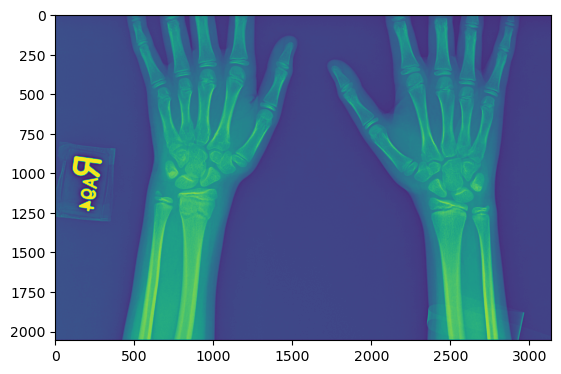

In [31]:
plt.imshow(fractured_img)

In [32]:
fractured_img.shape

(2056, 3138)

In [33]:
len(os.listdir(train_path+'/fractured'))

4480

In [34]:
len(os.listdir(train_path+'/not fractured'))

4383

In [46]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [51]:
train_datagen = ImageDataGenerator(
    rotation_range=15,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    width_shift_range=0.1,
    height_shift_range=0.1
)
val_datagen= ImageDataGenerator(    rotation_range=15,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    width_shift_range=0.1,
    height_shift_range=0.1)

In [64]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size = (224,224),
    batch_size = 4,
    class_mode = 'binary')
validation_generator = val_datagen.flow_from_directory(
    test_path,
    target_size = (224,224),
    batch_size = 4,
    shuffle=True,
    class_mode = 'binary')

Found 8863 images belonging to 2 classes.
Found 600 images belonging to 2 classes.


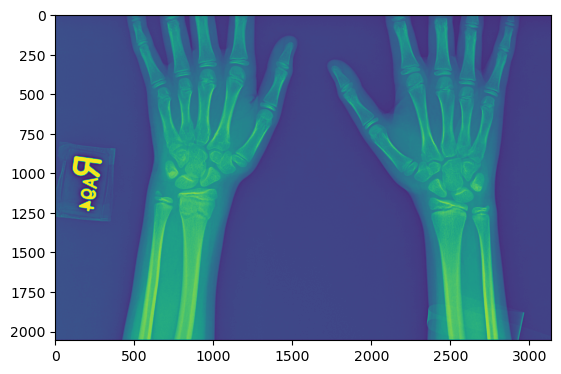

In [48]:
plt.imshow(para_img)

# Creating the Model

In [53]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import  Dropout, Flatten, Dense, Conv2D, MaxPooling2D

In [56]:
image_shape=(224,224,3)

In [57]:
model = Sequential()

model.add(Conv2D(filters=32, kernel_size=(3,3),input_shape=image_shape, activation='relu',))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(filters=64, kernel_size=(3,3),input_shape=image_shape, activation='relu',))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(filters=64, kernel_size=(3,3),input_shape=image_shape, activation='relu',))
model.add(MaxPooling2D(pool_size=(2, 2)))


model.add(Flatten())


model.add(Dense(128,activation='relu'))

# Dropouts help reduce overfitting by randomly turning neurons off during training.
# Here we say randomly turn off 50% of neurons.
model.add(Dropout(0.5))

# Last layer, remember its binary so we use sigmoid
model.add(Dense(1,activation='sigmoid'))

model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [58]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 111, 111, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 54, 54, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 52, 52, 64)        36928     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 26, 26, 64)       

## Early Stopping

In [59]:
from tensorflow.keras.callbacks import EarlyStopping

In [60]:
early_stop = EarlyStopping(monitor='val_loss',patience=2)

## Training the Model

In [61]:
batch_size = 16

In [65]:
train_image_gen.class_indices

{'fractured': 0, 'not fractured': 1}

In [66]:
import warnings
warnings.filterwarnings('ignore')

In [67]:
results = model.fit_generator(train_image_gen,epochs=5,
                              validation_data=test_image_gen,
                             callbacks=[early_stop])

Epoch 1/5
554/554 [==============================] - 101s 181ms/step - loss: 1.1333 - accuracy: 0.5101 - val_loss: 0.7094 - val_accuracy: 0.4283
Epoch 2/5
554/554 [==============================] - 102s 184ms/step - loss: 0.6898 - accuracy: 0.5231 - val_loss: 0.6880 - val_accuracy: 0.5417
Epoch 3/5
554/554 [==============================] - 102s 184ms/step - loss: 0.6883 - accuracy: 0.5209 - val_loss: 0.6844 - val_accuracy: 0.4950
Epoch 4/5
554/554 [==============================] - 105s 190ms/step - loss: 0.6877 - accuracy: 0.5206 - val_loss: 0.6849 - val_accuracy: 0.4533
Epoch 5/5
554/554 [==============================] - 102s 184ms/step - loss: 0.6869 - accuracy: 0.5312 - val_loss: 0.7003 - val_accuracy: 0.4133


In [68]:
from tensorflow.keras.models import load_model
model.save('fracture_model.h5')

# Evaluating the Model

In [69]:
losses = pd.DataFrame(model.history.history)

<Axes: >

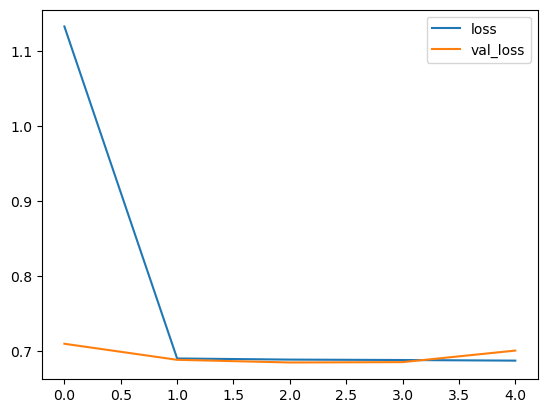

In [70]:
losses[['loss','val_loss']].plot()

In [71]:
model.metrics_names

['loss', 'accuracy']

In [72]:
model.evaluate_generator(test_image_gen)

[0.707916796207428, 0.4216666519641876]

In [73]:
from tensorflow.keras.preprocessing import image

In [74]:
# https://datascience.stackexchange.com/questions/13894/how-to-get-predictions-with-predict-generator-on-streaming-test-data-in-keras
pred_probabilities = model.predict_generator(test_image_gen)

In [75]:
pred_probabilities

array([[0.50620383],
       [0.47262764],
       [0.4841219 ],
       [0.00953754],
       [0.5193051 ],
       [0.5071151 ],
       [0.51647854],
       [0.52220315],
       [0.50415903],
       [0.4892164 ],
       [0.43526903],
       [0.48265848],
       [0.5136213 ],
       [0.32559606],
       [0.50024015],
       [0.4471388 ],
       [0.50660825],
       [0.46666616],
       [0.51338416],
       [0.51708585],
       [0.27414498],
       [0.51307875],
       [0.3479129 ],
       [0.22668602],
       [0.53401774],
       [0.372781  ],
       [0.3029455 ],
       [0.43212393],
       [0.5565096 ],
       [0.5464082 ],
       [0.47687984],
       [0.5155404 ],
       [0.48897636],
       [0.39860854],
       [0.49251264],
       [0.51929945],
       [0.5011638 ],
       [0.47422954],
       [0.02526016],
       [0.5087659 ],
       [0.51482403],
       [0.51462585],
       [0.51338416],
       [0.5260771 ],
       [0.52097785],
       [0.51490045],
       [0.51554537],
       [0.518

In [76]:
test_image_gen.classes

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [77]:
predictions = pred_probabilities > 0.5

In [78]:
predictions

array([[ True],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [False],
       [ True],
       [False],
       [ True],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [False],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [False],
       [ True],
       [ True],
       [ True],
       [

In [79]:
from sklearn.metrics import classification_report,confusion_matrix

In [80]:
print(classification_report(test_image_gen.classes,predictions))

              precision    recall  f1-score   support

           0       0.54      0.26      0.35       360
           1       0.38      0.68      0.48       240

    accuracy                           0.42       600
   macro avg       0.46      0.47      0.42       600
weighted avg       0.48      0.42      0.40       600



In [81]:
confusion_matrix(test_image_gen.classes,predictions)

array([[ 93, 267],
       [ 78, 162]])

# Predicting on an Image

In [84]:
fractured

'../data/Bone Fracture/train//fractured/63.jpg'

In [86]:
my_image = image.load_img(fractured,target_size=image_shape)

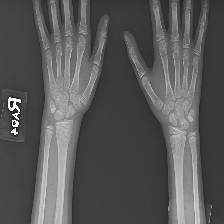

In [87]:
my_image

In [88]:
type(my_image)

PIL.Image.Image

In [89]:
my_image = image.img_to_array(my_image)

In [90]:
type(my_image)

numpy.ndarray

In [91]:
my_image.shape

(224, 224, 3)

In [92]:
my_image = np.expand_dims(my_image, axis=0)

In [93]:
my_image.shape

(1, 224, 224, 3)

In [94]:
model.predict(my_image)

1/1 [==============================] - 0s 38ms/step


array([[0.5133841]], dtype=float32)

In [95]:
train_image_gen.class_indices

{'fractured': 0, 'not fractured': 1}